In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string

In [2]:
df=pd.read_excel("Messy_Ecommerce_Sales_Dataset.xlsx")
df

,Order_ID,Order_Date,Customer_Name,City,State,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
0,71339,2024-05-01,Customer_179,Mumbai,MH,Furniture,Chair,2.0,17776.0,20,28441.60,7091.71,Card
1,53975,2024-12-06,Customer_31,Delhi,DL,Electronics,Laptop,7.0,65489.0,20,366738.40,71765.05,Net Banking
2,98419,2025-01-18,Customer_85,Mumbai,MH,Furniture,Table,7.0,21990.0,15,130840.50,21722.13,Net Banking
3,27306,2025-02-27,Customer_44,Bengaluru,KA,Electronics,Mouse,8.0,50434.0,20,322777.60,47562.15,Cash
4,53863,2024-04-02,Customer_249,Delhi,DL,Electronics,Keyboard,1.0,6526.0,15,5547.10,959.82,Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,44415,2024-06-29,Customer_149,Chennai,TN,Electronics,Laptop,7.0,76107.0,20,426199.20,69828.44,UPI
997,73921,2025-04-11,Customer_72,Hyderabad,TS,Office Supplies,Printer Paper,1.0,53041.0,5,50388.95,8772.55,UPI
998,93470,2024-06-01,Customer_88,Hyderabad,TS,Office Supplies,Pen,8.0,59225.0,20,379040.00,36256.09,Cash
999,55243,2024-12-08,Customer_86,Mumbai,MH,Furniture,Desk,5.0,25798.0,5,122540.50,11131.68,Cash


In [3]:
# i) let's understand the data
df.head()

,Order_ID,Order_Date,Customer_Name,City,State,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
0,71339,2024-05-01,Customer_179,Mumbai,MH,Furniture,Chair,2.0,17776.0,20,28441.6,7091.71,Card
1,53975,2024-12-06,Customer_31,Delhi,DL,Electronics,Laptop,7.0,65489.0,20,366738.4,71765.05,Net Banking
2,98419,2025-01-18,Customer_85,Mumbai,MH,Furniture,Table,7.0,21990.0,15,130840.5,21722.13,Net Banking
3,27306,2025-02-27,Customer_44,Bengaluru,KA,Electronics,Mouse,8.0,50434.0,20,322777.6,47562.15,Cash
4,53863,2024-04-02,Customer_249,Delhi,DL,Electronics,Keyboard,1.0,6526.0,15,5547.1,959.82,Card


In [4]:
df.tail()

,Order_ID,Order_Date,Customer_Name,City,State,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
996,44415,2024-06-29,Customer_149,Chennai,TN,Electronics,Laptop,7.0,76107.0,20,426199.20,69828.44,UPI
997,73921,2025-04-11,Customer_72,Hyderabad,TS,Office Supplies,Printer Paper,1.0,53041.0,5,50388.95,8772.55,UPI
998,93470,2024-06-01,Customer_88,Hyderabad,TS,Office Supplies,Pen,8.0,59225.0,20,379040.00,36256.09,Cash
999,55243,2024-12-08,Customer_86,Mumbai,MH,Furniture,Desk,5.0,25798.0,5,122540.50,11131.68,Cash
1000,69586,2024-03-30,Customer_110,Hyderabad,TS,Office Supplies,Printer Paper,4.0,41730.0,20,133536.00,14960.91,Cash


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1001 non-null   int64  
 1   Order_Date     1001 non-null   object 
 2   Customer_Name  1001 non-null   object 
 3   City           1001 non-null   object 
 4   State          1001 non-null   object 
 5   Category       1001 non-null   object 
 6   Product        1001 non-null   object 
 7   Quantity       1000 non-null   float64
 8   Unit_Price     1000 non-null   float64
 9   Discount       1001 non-null   int64  
 10  Sales          1001 non-null   float64
 11  Profit         1001 non-null   float64
 12  Payment_Mode   1001 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 101.8+ KB


In [6]:
df.describe()

,Order_ID,Quantity,Unit_Price,Discount,Sales,Profit
count,1001.000000,1000.000000,1000.000000,1001.000000,1001.000000,1001.000000
mean,55002.390609,4.461000,40481.732000,10.209790,162692.780519,29126.410659
std,25889.741749,2.295157,22999.062047,7.120811,133185.965887,27797.174576
min,10432.000000,1.000000,190.000000,0.000000,304.000000,56.170000
25%,31830.000000,2.000000,20707.750000,5.000000,54069.000000,7819.140000
50%,54680.000000,4.000000,41164.500000,10.000000,124164.000000,20179.070000
75%,77649.000000,6.000000,60235.750000,15.000000,247144.000000,41697.190000
max,99932.000000,8.000000,79957.000000,20.000000,572768.000000,141563.800000


In [7]:
df.nunique()  # means in order_id 997 unique rows

Order_ID          997
Order_Date        447
Customer_Name     247
City                7
State               5
Category            4
Product            10
Quantity            8
Unit_Price        993
Discount            5
Sales             998
Profit           1000
Payment_Mode        4
dtype: int64

In [8]:
df.isnull()

,Order_ID,Order_Date,Customer_Name,City,State,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False
999,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()  # in every colums we got the sum oif null values

Order_ID         0
Order_Date       0
Customer_Name    0
City             0
State            0
Category         0
Product          0
Quantity         1
Unit_Price       1
Discount         0
Sales            0
Profit           0
Payment_Mode     0
dtype: int64

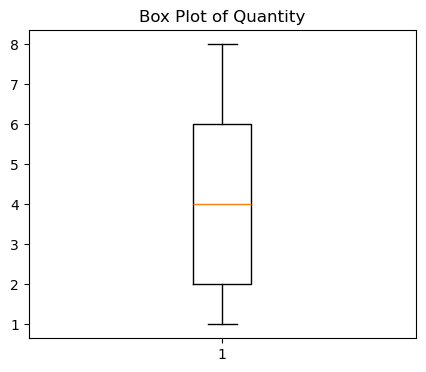

In [10]:
# we found the null values in quantity and unit_price we need to fill with men for taht we check the outlier
plt.figure(figsize=(5,4))
plt.boxplot(df["Quantity"].dropna())
plt.title("Box Plot of Quantity")
plt.show()

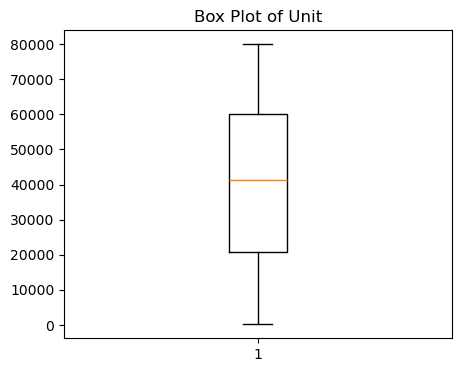

In [11]:
plt.figure(figsize=(5,4))
plt.boxplot(df["Unit_Price"].dropna())
plt.title("Box Plot of Unit")
plt.show()

In [12]:
df['Order_ID'].duplicated().sum() # here we got the order_id duplictes based on taht we can remove duplicates rows entire docouments

np.int64(4)

In [13]:
df['Quantity']

0       2.0
1       7.0
2       7.0
3       8.0
4       1.0
       ... 
996     7.0
997     1.0
998     8.0
999     5.0
1000    4.0
Name: Quantity, Length: 1001, dtype: float64

In [14]:
# 2)now cleaing the data

# i) cleaing the missing data:

# firstly fill Quantity with mean
mean=df['Quantity'].mean()
df['Quantity']=df['Quantity'].fillna(mean)


In [15]:
df['Quantity'].isnull().sum()   # Verify that all missing values have been filled

np.int64(0)

In [16]:
 # now fill Unit_Price
mean=df['Unit_Price'].mean()                      # cal the mean for Unit_colu
df['Unit_Price']=df['Unit_Price'].fillna(mean)    # filling null values with mean
   

In [17]:
df['Unit_Price'].isnull().sum()     # Verify that all missing values have been filled

np.int64(0)

In [18]:
# ii) handling duplictes value's
df['Order_ID'].duplicated().sum()      # cal the duplictes value in order_id




np.int64(4)

In [19]:
# printing the duplicate's values
df[df['Order_ID'].duplicated(keep=False)]    # return duplicet's with all occurance

,Order_ID,Order_Date,Customer_Name,City,State,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
98,69586,2024-03-30,Customer_110,Hyderabad,TS,Office Supplies,Printer Paper,4.0,41730.0,20,133536.00,14960.91,Cash
264,45535,2024-08-11,Customer_217,Bengaluru,KA,Electronics,Keyboard,6.0,12516.0,10,67586.40,12946.73,Card
310,45535,2025-02-03,Customer_151,Hyderabad,TS,Office Supplies,Notebook,4.0,4744.0,10,17078.40,2709.07,UPI
418,51852,2024-10-07,Customer_188,Delhi,DL,Furniture,Desk,3.0,6299.0,15,16062.45,3309.30,Net Banking
427,11304,2024-03-21,Customer_164,Mumbai,MH,Furniture,Table,6.0,74218.0,20,356246.40,63075.59,Net Banking
470,11304,2025-04-30,Customer_128,Delhi,DL,Electronics,Laptop,2.0,57356.0,10,103240.80,28465.37,UPI
882,51852,2024-05-27,Customer_163,Hyderabad,TS,Office Supplies,Pen,3.0,58209.0,0,174627.00,50637.48,Cash
1000,69586,2024-03-30,Customer_110,Hyderabad,TS,Office Supplies,Printer Paper,4.0,41730.0,20,133536.00,14960.91,Cash


In [21]:
# dropping duplicaet's values
df=df.drop_duplicates(subset='Order_ID')   # only column values removed we need 



In [25]:
# checking the unique values
df['Category'].unique()
# here we observe the 2 Electronics means spelling mistak


array(['Furniture', 'Electronics', 'Office Supplies', 'Electornic'],
      dtype=object)

In [46]:
# let's replace it+
df['Category']=df['Category'].replace('Electornics','Electronics')
df

,Order_ID,Order_Date,Customer_Name,City,State,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
0,71339,2024-05-01,Customer_179,Mumbai,Maharashtra,Furniture,Chair,2.0,17776.0,20,28441.60,7091.71,Card
1,53975,2024-12-06,Customer_31,Delhi,Delhi,Electronics,Laptop,7.0,65489.0,20,366738.40,71765.05,Net Banking
2,98419,2025-01-18,Customer_85,Mumbai,Maharashtra,Furniture,Table,7.0,21990.0,15,130840.50,21722.13,Net Banking
3,27306,2025-02-27,Customer_44,Bengaluru,Karnataka,Electronics,Mouse,8.0,50434.0,20,322777.60,47562.15,Cash
4,53863,2024-04-02,Customer_249,Delhi,Delhi,Electronics,Keyboard,1.0,6526.0,15,5547.10,959.82,Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,85073,2024-11-03,Customer_60,Bengaluru,Karnataka,Furniture,Desk,8.0,71233.0,15,484384.40,136379.63,Cash
996,44415,2024-06-29,Customer_149,Chennai,Tamil Nadu,Electronics,Laptop,7.0,76107.0,20,426199.20,69828.44,UPI
997,73921,2025-04-11,Customer_72,Hyderabad,Telangana,Office Supplies,Printer Paper,1.0,53041.0,5,50388.95,8772.55,UPI
998,93470,2024-06-01,Customer_88,Hyderabad,Telangana,Office Supplies,Pen,8.0,59225.0,20,379040.00,36256.09,Cash


In [47]:
df['State'].unique()

array(['Maharashtra', 'Delhi', 'Karnataka', 'Telangana', 'Tamil Nadu'],
      dtype=object)

In [48]:
df['State']=df['State'].replace({'MH':'Maharashtra','DL': 'Delhi','KA': 'Karnataka','TS':'Telangana','TN':'Tamil Nadu'})

In [40]:
df['Product']=df['Product'].str.strip()

In [43]:
df['Customer_Name']=df['Customer_Name'].str.strip()

In [45]:
df['Product']=df['Product'].str.strip()

In [ ]:
# Now Visulization part start

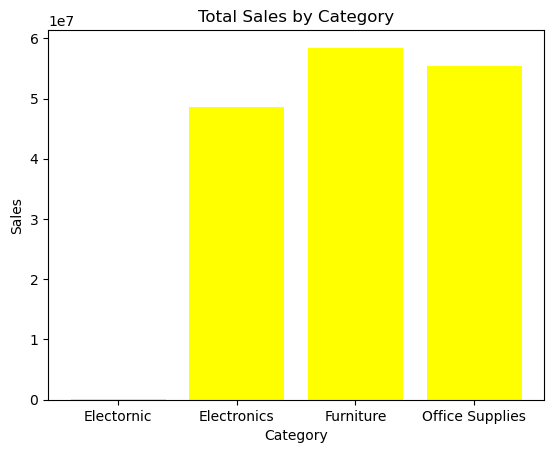

In [61]:
category_sales = df.groupby('Category')['Sales'].sum()   
 
plt.bar(category_sales.index, category_sales.values,color='yellow')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

<BarContainer object of 5 artists>

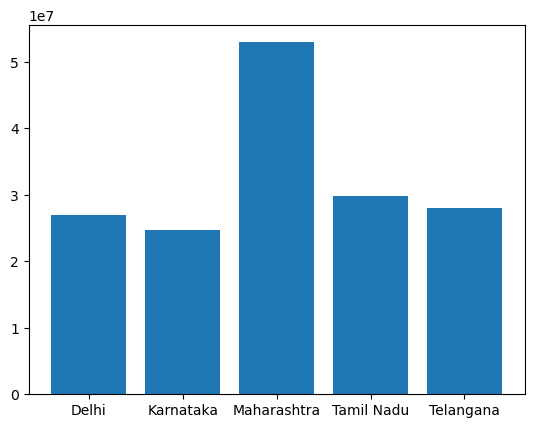

In [ ]:
country_sales=df.groupby('State')['Sales'].sum()
plt.bar(country_sales.index,country_sales.values)
plt.xlabel('State')
plt.ylabel('Sales')

Payment_Mode
Cash           272
Net Banking    248
UPI            239
Card           238
Name: count, dtype: int64


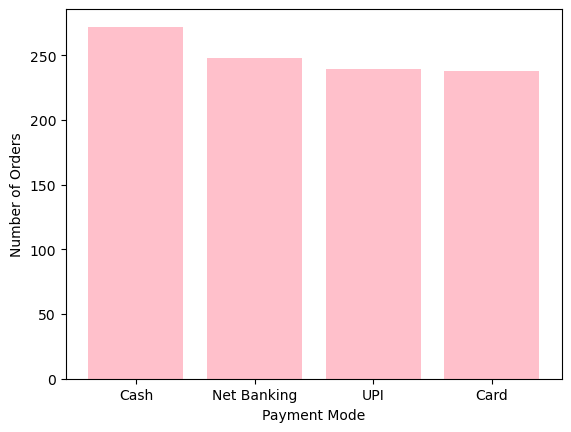

In [60]:
payment_mode=df['Payment_Mode'].value_counts()
print(payment_mode)
plt.bar(payment_mode.index,payment_mode.values,color='pink')
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")
plt.show()
